# IRKGL16 vs explicit symplectic integrators (Hénon Heiles)

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.2**:

    - **Figure 2(c)**, saved as **`Fig5.pdf`**
    - **Figure 2(d)**, saved as **`Fig6.pdf`**


- **From Section 3.1.2**

    - **Figure 5(c)**, saved as **`Fig12.pdf`**
    - **Figure 5(d)**, saved as **`Fig13.pdf`**
    - **Figure 6(b)**, saved as **`Fig15.pdf`**
    - **Figure 8(a)**, saved as **`Fig18.pdf`**
    - **Figure 8(b)**, saved as **`Fig19.pdf`**

<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-Hénon-Heiles">Initial value problem: Hénon-Heiles</a></li>
    <li><a href="#IRKGL16-integrations">IRKGL16-integrations</a></li>
    <ul>
        <li><a href="#Comparison-of-IRKGL-schemes">Comparison of IRKGL schemes</a></li>
    </ul>
    <li><a href="#2nd-order-explicit-symplectic-integrations">2nd order explicit symplectic integrations</a></li>
    <li><a href="#Benchmarks-diagrams">Benchmarks diagrams</a></li>
    <ul>
        <li><a href="#Work-precison-diagrams">Work-precison-diagrams</a></li>
        <li><a href="#Error-in-Energy">Error in Energy</a></li>
        <li><a href="#Error-in-Solution">Error in Solution</a></li>
    </ul>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using BenchmarkTools
using IRKGaussLegendre

PATH_Splitting="../../"
include(string(PATH_Splitting,"/src/SplittingMethods.jl"))
using .SplittingMethods  

Base.@boundscheck false
pkgversion(IRKGaussLegendre) # must be v"0.2.13" or greater

v"0.2.13"

### Utils

In [2]:
mutable struct tsolutions_IRKGL16
    dts
    sols
    retcodes
    iters
    cpus
    fcns
    MaxΔHglobal
    MaxΔHlocal
    wcpu
    cpu_idx
end

function run_many_IRKGL16(alg, prob, ddt0, HAM; wcpu=true)

    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    iters=zero(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]
    
    sols=Array{IRKGaussLegendre.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B,parms_B)
    
    for i in 1:length(ddt0)
        
        print(",",ddt0[i])    
        dt0=ddt0[i]
        
        sols[i]=solve(prob,alg,dt=dt0, adaptive=false)
        if sols[i].retcode==ReturnCode.Success
           iters[i]=sols[i].stats.nfpiter
           fcns[i]=iters[i]*8
        else
           retcodes[i]=false
           iters[i]=Inf
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solve(prob,alg, dt=dt0, adaptive=false, save_everystep = false)
            cpus[i]= @belapsed solve($prob,$alg, dt=$dt0, adaptive=false, save_everystep = false)
        end
        
    end

    println("")
    return tsolutions_IRKGL16(ddt0, sols,retcodes,iters,cpus,fcns,MaxΔHglobal,MaxΔHlocal,wcpu,-1)

end  

run_many_IRKGL16 (generic function with 1 method)

In [3]:
mutable struct tsolutions_Splitting
   s
   r
   alg
   dts
   sols
   retcodes
  # nflowsH3
   cpus
   fcns 
   MaxΔHglobal
   MaxΔHlocal
   wcpu 
   cpu_idx
end

function run_many_Splitting(s, r, alg, prob, ddt0, HAM; wcpu=true)
    
    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    #nflowsH3=similar(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]

    sols=Array{SplittingMethods.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B, parms_B)

    for i in 1:length(ddt0)

        print(",",ddt0[i])
        dt0=ddt0[i]  

        # save_everystep=true
        m0=1
        sols[i]=solver_Splitting(prob, alg, dt=dt0)

        if sols[i].success
           fcns[i]=sols[i].stats.naccept*s 
        else
           retcodes[i]=false
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solver_Splitting(prob, alg, dt=dt0, save_everystep=false)
            cpus[i]=@belapsed solver_Splitting($prob, $alg, dt=$dt0, save_everystep=false)
        end
    end

    println("")
    return tsolutions_Splitting(s, r, alg, ddt0, sols,retcodes,cpus,fcns, MaxΔHglobal,MaxΔHlocal,wcpu,-1)
 
end

run_many_Splitting (generic function with 1 method)

In [4]:
function find_index_ge_cpu(lookup_value, v)

   idx=0
   for k in length(v):-1:1

       if v[k]>=lookup_value
          idx=k
          break
       end

   end

   return idx

end

function compute_index_ge_cpu!(indexes, lookup_value, manysols)

   for i  in 1:length(manysols)

      if manysols[i].wcpu  
         idx=find_index_ge_cpu(lookup_value, manysols[i].cpus)
         push!(indexes,idx)
      else
         push!(indexes,-1)
      end
   end

   return nothing

end

function lcm_floats_vector(numbers::Vector{Float64})
   # Convert the numbers to rationals
   rationals = rationalize.(numbers)
   # Compute the LCM iteratively
   lcm_rationals = reduce(lcm, rationals)
   return lcm_rationals
end

lcm_floats_vector (generic function with 1 method)

##### <a href="#top">Back to the top</a>

## Initial value problem: Hénon-Heiles

We consider the Hénon-Heiles model which is Hamiltonian with

\begin{align*}
H(q,p)=\frac{1}{2} (p_1^2+p_2^2)+\frac{1}{2}(q_1^2+q_2^2)+q_1^2q_2-\frac{1}{3}q_2^3
\end{align*}

and the corresponding system

\begin{align*}
& \frac{dq_1}{dt}=p_1, \quad 
\frac{dq_2}{dt}=p_2, \\
& \frac{dp_1}{dt}=-q_1-2q_1q_2, \quad 
 \frac{dp_2}{dt}=-q_2-q_1^2+q_2^2
\end{align*}

In [5]:
function Potential_U(q1,q2)


    return 1/2*(q1*q1+q2*q2)+q1*q1*q2-1/3*q2*q2*q2

end

function HenonHeliesHam(u,parms)

    q1=u[1]
    q2=u[2]
    p1=u[3]
    p2=u[4]
    
    U=Potential_U(q1,q2)
    
    return 1/2*(p1*p1+p2*p2)+U

end


function HenonHeliesHam(u)

    return HenonHeliesHam(u,[])

end

function HenonHeilesODE!(du,u,parms,t)

  q1=u[1]
  q2=u[2]
  p1=u[3]
  p2=u[4]

  du[1]=p1
  du[2]=p2
  
  du[3]=-q1-2*q1*q2
  du[4]=-q2-q1*q1+q2*q2
  
  return nothing
  
end

function flowH1HenonHeiles!(uj,ej,h,parms)

   q1=uj[1]
   q2=uj[2]
   p1=uj[3]
   p2=uj[4]

   uj[1]=q1+h*p1
   uj[2]=q2+h*p2

   return nothing

end


function flowH2HenonHeiles!(uj,ej,h,parms)

    q1=uj[1]
    q2=uj[2]
    p1=uj[3]
    p2=uj[4]
 
    uj[3]=p1+h*(-q1-2*q1*q2)
    uj[4]=p2+h*(-q2-q1*q1+q2*q2)

    return nothing
 
 end

flowH2HenonHeiles! (generic function with 1 method)

In [6]:
# Gemetric Numerical Integration. Structure-Preserving Algorithms for Ordinary Differential Equations, page 15

q0=[0,3/10]
p0=[0, 2/10]

# Non-Chaotic solution H0=1/12

H0=1/12
U0=Potential_U(q0[1],q0[2])
p0[1]=sqrt(2*H0-2*U0-p0[2]^2)
parms = [0.]

u0=vcat(q0,p0)
u0_B=BigFloat.(u0)

t0 = 0.
tF = 2*pi*1e4 #2*pi*1e4
tspan=(t0,tF);

prob = ODEProblem{true,SciMLBase.FullSpecialize}(HenonHeilesODE!, u0, tspan, parms)

HAM=HenonHeliesHam
@show(HAM(u0, parms));

HAM(u0, parms) = 0.08333333333333333


##### <a href="#top">Back to the top</a>

## IRKGL16 integrations (s=8)


In [7]:
ddt0_irk16=collect(1/4:1/4:3)  

println("simd")
alg=IRKGL16(simd=true, fseq=false, second_order_ode=true)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM)
#
println("seq")
alg=IRKGL16(simd=false, fseq=true, second_order_ode=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM)
#
println("hybr")
alg=IRKGL16(simd=true, fseq=true, second_order_ode=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM);

simd
,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0
seq
,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0
hybr
,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


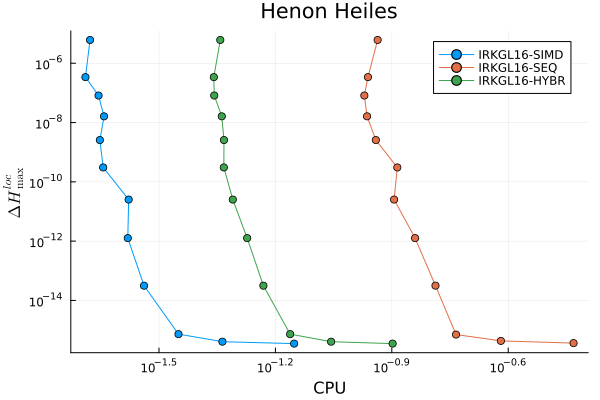

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [8]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Henon Heiles", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

<a href="#top">Back to the top</a>

## 2nd order explicit symplectic integrations

In [9]:
flows=[flowH1HenonHeiles!, flowH2HenonHeiles!]
prob_split=SplittingProblem(flows, u0, tspan, parms)

HAM=HenonHeliesHam
@show(HAM(u0,parms))

HAM(u0, parms) = 0.08333333333333333


0.08333333333333333

### Composition methods

In [10]:
ddt0_split=vcat(collect(1/2^8:1/2^9:7/2^9), collect(2/2^7:1/2^7:1/2^3))


println("Strang: s=1")
s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2=run_many_Splitting(s, r, alg, prob_split, ddt0_split, HAM, wcpu=true)

#
println("SUZ90: s=5")
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAM, wcpu=true)
#
println("SS05: s=13")
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAM, wcpu=true)
#
println("SS05: s=21")
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAM, wcpu=true)
#
println("SS05: s=35")
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAM, wcpu=true);

Strang: s=1
,0.00390625,0.005859375,0.0078125,0.009765625,0.01171875,0.013671875,0.015625,0.0234375,0.03125,0.0390625,0.046875,0.0546875,0.0625,0.0703125,0.078125,0.0859375,0.09375,0.1015625,0.109375,0.1171875,0.125
SUZ90: s=5
,0.01953125,0.029296875,0.0390625,0.048828125,0.05859375,0.068359375,0.078125,0.1171875,0.15625,0.1953125,0.234375,0.2734375,0.3125,0.3515625,0.390625,0.4296875,0.46875,0.5078125,0.546875,0.5859375,0.625
SS05: s=13
,0.05078125,0.076171875,0.1015625,0.126953125,0.15234375,0.177734375,0.203125,0.3046875,0.40625,0.5078125,0.609375,0.7109375,0.8125,0.9140625,1.015625,1.1171875,1.21875,1.3203125,1.421875,1.5234375,1.625
SS05: s=21
,0.08203125,0.123046875,0.1640625,0.205078125,0.24609375,0.287109375,0.328125,0.4921875,0.65625,0.8203125,0.984375,1.1484375,1.3125,1.4765625,1.640625,1.8046875,1.96875,2.1328125,2.296875,2.4609375,2.625
SS05: s=35
,0.13671875,0.205078125,0.2734375,0.341796875,0.41015625,0.478515625,0.546875,0.8203125,1.09375,1.3671875,1.640625,1.9140625,2.1

### RKN symplectic integrations

In [11]:
println("BM02: s=14")
s=14; r=6
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn6=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAM, wcpu=true)

println("BCE22: s=19")
s=19; r=8; rkn=true
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn8=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAM, wcpu=true);

BM02: s=14
,0.0546875,0.08203125,0.109375,0.13671875,0.1640625,0.19140625,0.21875,0.328125,0.4375,0.546875,0.65625,0.765625,0.875,0.984375,1.09375,1.203125,1.3125,1.421875,1.53125,1.640625,1.75
BCE22: s=19
,0.07421875,0.111328125,0.1484375,0.185546875,0.22265625,0.259765625,0.296875,0.4453125,0.59375,0.7421875,0.890625,1.0390625,1.1875,1.3359375,1.484375,1.6328125,1.78125,1.9296875,2.078125,2.2265625,2.375


<a href="#top">Back to the top</a>

## Benchmarks diagrams


In [12]:
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
           sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10,
           sols_split_rkn6, sols_split_rkn8]

#=
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
           sols_split_r8, 
           sols_split_rkn6, sols_split_rkn8]
=#

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)", 
              "BM02(rkn6)", "BCE22(rkn8)" ]

#=
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
              "SS05(r=8)", 
              "BM02(rkn6)", "BCE22(rkn8)" ]
=#

colors2plot = [:red, :blue, :green, 
               :orange, :purple, :cyan, :magenta, :teal, 
               :gold, :gray];

#=
colors2plot = [:red, :blue, :green, 
               :magenta,  
               :gold, :gray];
=#

### Work-precison diagrams

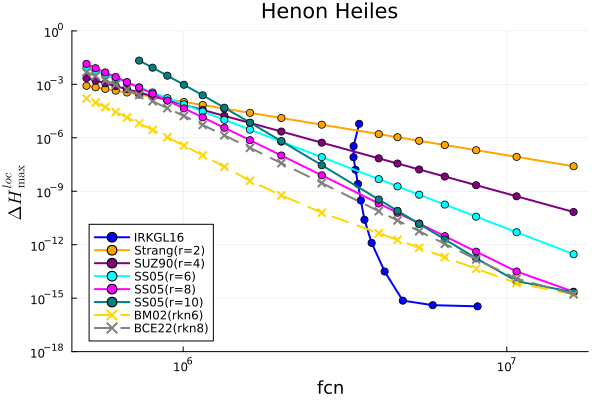

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [36]:
yrange=(1e-18, 1e0)

sols=sols2plot[1]

pl3=plot(sols.fcns,sols.MaxΔHlocal, scale=:log10,
         markershape=:circle, lw=2,
         ylimits=yrange,    
         label="IRKGL16", color=colors2plot[2],
         title="Henon Heiles", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         legend=:bottomleft,
         guidefont=font(12), labelsize=10)


for i in 4:length(sols2plot)
       
   sols=sols2plot[i]
    
   if occursin("rkn", labels2plot[i])
       plot!(pl3, sols.fcns , sols.MaxΔHlocal, 
       markershape=:xcross, lw=2, ls=:dash,
       label=labels2plot[i], color=colors2plot[i],
       scale=:log10)
        
   else 
       plot!(pl3, sols.fcns , sols.MaxΔHlocal, 
             markershape=:circle, lw=2,
             label=labels2plot[i], color=colors2plot[i],
             scale=:log10)
   end

end

display(pl3)

In [37]:
savefig("./figures/Fig12.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-3- Numerical comprarisons of IRKGL16 with explicit symplectic integrators/figures/Fig12.pdf"

### Select integration with same CPU-time

#### SIMD

In [15]:
sols=sols2plot[1]
@show labels2plot[1]
[sols.MaxΔHlocal sols.cpus]

labels2plot[1] = "IRKGL16-SIMD"


12×2 Matrix{Float64}:
 3.488e-16    0.0705196
 4.0507e-16   0.04607
 7.27045e-16  0.0355011
 3.13698e-14  0.0289385
 1.26421e-12  0.0262764
 2.5221e-11   0.0264175
 3.05756e-10  0.0227071
 2.56567e-9   0.0222664
 1.6192e-8    0.0228227
 8.15254e-8   0.0220931
 3.40396e-7   0.0204393
 6.09815e-6   0.0210029

In [39]:
index0=3  # IRKGL16: index0=4 (exact solution)
idx=4     # IRKGL16:  index1=8 optimum step-size

index=[idx]
compute_index_ge_cpu!(index, sols_irk16_simd.cpus[idx], sols2plot[2:end])

println("Checking CPU times")

for i in 1:length(index)
    
    k=index[i]
    if sols2plot[i].wcpu
       sols2plot[i].cpu_idx=k
       println(k, " , ", labels2plot[i], " , ", sols2plot[i].dts[k], " , ", sols2plot[i].cpus[k])
    end
    
end

Checking CPU times
4 , IRKGL16-SIMD , 1.0 , 0.028938527
12 , IRKGL16-SEQ , 3.0 , 0.115731412
12 , IRKGL16-HYBR , 3.0 , 0.045497802
12 , Strang(r=2) , 0.0546875 , 0.030449318
8 , SUZ90(r=4) , 0.1171875 , 0.037505635
8 , SS05(r=6) , 0.3046875 , 0.03269455
8 , SS05(r=8) , 0.4921875 , 0.038266215
8 , SS05(r=10) , 0.8203125 , 0.031420469
8 , BM02(rkn6) , 0.328125 , 0.031593319
8 , BCE22(rkn8) , 0.4453125 , 0.030916587


#### Adjust step-size for splitting integrations


In [17]:
IRKGL16_cpu=sols2plot[1].cpus[idx];

##### Strangr2

In [18]:
idx_met=4
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ] )

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    strangr2=run_many_Splitting(s, r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] strangr2.dts strangr2.cpus strangr2.MaxΔHlocal])
end


Any[0.028938527 "Strang(r=2)" 0.0546875 0.030449318]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.0625
Strang(r=2),r=2,s=1
,0.0625
Any[0.028938527 "Strang(r=2)" 0.0625 0.029195349 0.00010301479802989279]


##### SUZ90r4

In [19]:
idx_met=5
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    suz90r4=run_many_Splitting(s, r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] suz90r4.dts suz90r4.cpus suz90r4.MaxΔHlocal])
end


Any[0.028938527 "SUZ90(r=4)" 0.1171875 0.037505635]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.15625
SUZ90(r=4),r=4,s=5
,0.15625
Any[0.028938527 "SUZ90(r=4)" 0.15625 0.028147678 2.239701297574402e-6]


##### SS05r6

In [20]:

idx_met=6
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r6=run_many_Splitting(s, r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r6.dts ss05r6.cpus ss05r6.MaxΔHlocal])
end


Any[0.028938527 "SS05(r=6)" 0.3046875 0.03269455]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.34375
SS05(r=6),r=6,s=13
,0.34375
Any[0.028938527 "SS05(r=6)" 0.34375 0.029174496 1.8947642729170908e-7]


##### SS05r8

In [40]:
idx_met=7 #4
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 
    h2=0.5

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r8=run_many_Splitting(s, r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r8.dts ss05r8.cpus ss05r8.MaxΔHlocal])
end

Any[0.028938527 "SS05(r=8)" 0.4921875 0.038266215]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.65625
SS05(r=8),r=8,s=21
,0.5
Any[0.028938527 "SS05(r=8)" 0.5 0.031248383 8.977400428831878e-9]


##### SS05r10

In [22]:
idx_met=8
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r10=run_many_Splitting(s,r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r10.dts ss05r10.cpus ss05r10.MaxΔHlocal])

end


Any[0.028938527 "SS05(r=10)" 0.8203125 0.031420469]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.890625
SS05(r=10),r=10,s=35
,0.890625
Any[0.028938527 "SS05(r=10)" 0.890625 0.029029678 7.034944495905038e-8]


##### BM02r6

In [23]:
idx_met=9 #5  
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=true)
    bm02r6=run_many_Splitting(s, r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] bm02r6.dts bm02r6.cpus bm02r6.MaxΔHlocal])

end

Any[0.028938527 "BM02(rkn6)" 0.328125 0.031593319]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.359375
BM02(rkn6),r=6,s=14
,0.359375
Any[0.028938527 "BM02(rkn6)" 0.359375 0.031038115 1.2325015869584839e-10]


##### BCE22

In [41]:
idx_met=10 #6 
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ] )

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=round(h1*T1/T2; digits=6, base=2) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=true)
    bce22r8=run_many_Splitting(s, r, alg, prob_split, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] bce22r8.dts bce22r8.cpus bce22r8.MaxΔHlocal])

end

Any[0.028938527 "BCE22(rkn8)" 0.4453125 0.030916587]
h2 = round((h1 * T1) / T2; digits = 6, base = 2) = 0.46875
BCE22(rkn8),r=8,s=19
,0.46875
Any[0.028938527 "BCE22(rkn8)" 0.46875 0.029291875 4.564415953438313e-9]


#### Work-precision diagramas (CPUS)

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


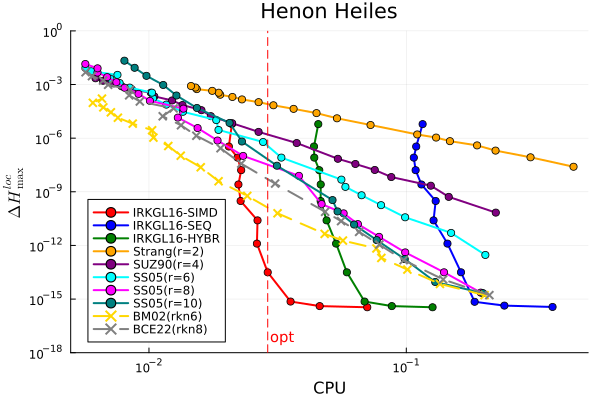

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [42]:
yrange=(1e-18, 1e0)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=:circle, lw=2,
          ylimits=yrange, 
          label=labels2plot[1], color=colors2plot[1],
          legend=:bottomleft,
          title="Henon Heiles", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]

    if sols.wcpu
        if occursin("rkn", labels2plot[i])
            
            plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
            markershape=:xcross, lw=2, ls=:dash,
            label=labels2plot[i], color=colors2plot[i],
            scale=:log10)
        
        else
            plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
            markershape=:circle, lw=2,
            label=labels2plot[i], color=colors2plot[i],
            scale=:log10)
        end
    end
    
end

vline!(pl1, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
annotate!((sols_irk16_simd.cpus[index[1]]+0.38, 0.05), text("opt", :red, 10, :center))


#### Resume

In [43]:
# simd
i=1
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_simd=cpu/fcn
# seq
i=2
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_seq=cpu/fcn
# hybr
i=3
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_hybr=cpu/fcn

#####################################

cpu=ss05r8.cpus[1]
fcn=ss05r8.fcns[1]
MaxΔHlocal=ss05r8.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("SS05(r=8)", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)

#####################################

cpu=bm02r6.cpus[1]
fcn=bm02r6.fcns[1]
MaxΔHlocal=bm02r6.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("BM02", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)

#####################################

cpu=bce22r8.cpus[1]
fcn=bce22r8.fcns[1]
MaxΔHlocal=bce22r8.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("BCE22", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)




SS05(r=8),seq=2.776643333115898,hybr=1.098424615730693,simd=0.582754203994524
MaxΔHlocal,seq=nothing,hybr=nothing,simd=8.977400428831878e-9
BM02,seq=2.5928865528814034,hybr=1.025731458381427,simd=0.5441878404587434
MaxΔHlocal,seq=nothing,hybr=nothing,simd=1.2325015869584839e-10
BCE22,seq=2.858675105835802,hybr=1.1308759274828772,simd=0.5999708050046373
MaxΔHlocal,seq=nothing,hybr=nothing,simd=4.564415953438313e-9


<a href="#top">Back to the top</a>

### Error in Energy

In [44]:
methods2plot=[sols_irk16_simd,
              sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10,
              sols_split_rkn6, sols_split_rkn8]
#=
methods2plot=[sols_irk16_simd, ss05r8, bm02r6, bce22r8]
=#

labels2plot_=["IRKGL16-SIMD", 
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)", 
              "BM02(rkn6)", "BCE22(rkn8)" ]
#=
labels2plot_=["IRKGL16-SIMD",  "SS05(r=8)", "BM02(rkn6)", "BCE22(rkn8)" ]
=#

colors2plot_ = [:red, 
                 :orange, :purple, :cyan, :magenta, :teal, 
                 :gold, :gray];

#=
colors2plot_ = [:red, 
                :magenta,
                :gold, :gray];
=#

In [ ]:
yrange=(1e-16, 1e-2)

pl3=plot(title="Henon Heiles",
         xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",
         ylimits=yrange, yscale=:log10, legend=:topleft)


HAM=HenonHeliesHam
H0=HAM(u0_B,parms)
H = [HAM(BigFloat.(u),parms) for u in sols_irk16_simd.sols[index[1]].u]
ΔH0 = @. Float64(abs(H/H0-1))

m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_irk16[index[1]])),1000))

plot!(sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0[2:m0:end]),
        ylimits=yrange,
        xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",title="Henon Heiles",
        label=labels2plot_[1],color=colors2plot_[1],
        yscale=:log10, legend=:topright)


# splitting

for k in 2:length(methods2plot)

    if methods2plot[k].wcpu
        #idx=methods2plot[k].cpu_idx
        idx=1
        solk=methods2plot[k].sols[idx]
        dt_split=methods2plot[k].dts[idx]
        m0 = max(1,div(Int64(ceil((tF-t0)/dt_split)),1000))
        labelk=labels2plot_[k]
        colork=colors2plot_[k]
        
        H = [HAM(BigFloat.(u),parms) for u in solk.u]
        ΔH0 = @. Float64(abs(H/H0-1))
        plot!(pl3, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10, label=labelk, color=colork)
    end

    
end

plot(pl3)

In [ ]:
savefig("./figures/Fig15.pdf")

In [ ]:
1+1

<a href="#top">Back to the top</a>

### Error in Solution

In [ ]:
methods2plot=[sols_irk16_simd,
              ss05r8, 
              bm02r6, bce22r8]


labels2plot_er=["IRKGL16-SIMD",  "SS05r8", "BM02(rkn6)", "BCE22(rkn8)"] 

colors2plot_er=[:red,  
                :magenta, 
                :gold, :gray];

In [ ]:
yrange=(1e-16, 1e-2)


ploterr_q=plot(title="Henon Heiles",
                ylims=yrange,
                yscale=:log10,
                legend=:bottomright,
                xlabel="t",
                ylabel="error in position")

ploterr_p=plot(title="Henon Heiles",
                ylims=yrange,
                yscale=:log10,
                legend=:bottomright,
                xlabel="t",
                ylabel="error in momentum")


for k in 1:length(methods2plot)

    if methods2plot[k].wcpu  

        #idx=methods2plot[k].cpu_idx
        idx=1
        errors2plot=methods2plot[k].sols[idx]
        ddt02plot=methods2plot[k].dts[idx]
        
        w=lcm_floats_vector(vcat(ddt0_irk16[index0],ddt02plot))
        ii=Int64.(w./(vcat(ddt0_irk16[index0],ddt02plot))).+1
        #ii=Int64.(round.(w./(vcat(ddt0_irk16[index0],ddt02plot))))
    
        println("k=",k, ". w=", w, ",ii=",ii)
    
    
        v0=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:3*ii[1]] 
        v1=errors2plot.t[ii[2]:ii[2]-1:3*ii[2]]
        
        println("k=", k, ",",labels2plot_er[k],",", v0 )
        println("k=", k, ",",labels2plot_er[k],",", v1 )
        println("*****************************")
        
       
        errorq=map((u,u1)->norm(BigFloat.(u[1:2])-BigFloat.(u1[1:2]))/norm(BigFloat.(u1[1:2])), 
                          errors2plot.u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
    
        errorp=map((u,u1)->norm(BigFloat.(u[3:4])-BigFloat.(u1[3:4]))/norm(BigFloat.(u1[3:4])), 
                          errors2plot.u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
          
        
        #tt=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:end]
        tt=errors2plot.t[ii[2]:ii[2]-1:end]
        
        plot!(ploterr_q, tt, errorq,
              label=labels2plot_er[k],color=colors2plot_er[k])
        
        plot!(ploterr_p, tt, errorp,
              label=labels2plot_er[k],color=colors2plot_er[k])

    end
    
end

In [ ]:
plot(ploterr_q)

In [ ]:
savefig("./figures/Fig18.pdf")

In [ ]:
plot(ploterr_p)


In [ ]:
savefig("./figures/Fig19.pdf")